# Basic FCGR Collections
<br>
An `FCGRCollection` is a container for multiple FCGR objects that share the
same representation space.

It is designed to store and analyze multiple FCGR representations together,
for example by calculating statistical summaries across their FCGR matrices.

The FCGRs in a collection must use identical representation parameters,
including the symbols used for the representation, the matrix resolution,
and CGR parameters.

In [1]:
from kaospy import FCGRCollection
from kaospy import FCGR
import matplotlib.pyplot as plt
import numpy as np

<br>

## Constructing a FCGR

<br>
Sequences used to create the collection:

In [2]:
sequences = {
    "seq1": "ABRACADABRA",
    "seq2": "SIMSALABIM",
}


<br>
The sequences are converted into FCGR objects and stored in a collection
using the specified representation parameters.

In [3]:
collection = FCGRCollection(
    sequences,
    resolution=16,
    symbols="LETTERS"
)

<br>

## Accessing Collection Parameters

In [4]:
collection.fcgr_names()

['seq1', 'seq2']

In [5]:
collection.fcgrs

{'seq1': FCGR(sequence_length=11, symbols=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], resolution=16, scaling_factor=0.8924295095562085, radius=1.0),
 'seq2': FCGR(sequence_length=10, symbols=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], resolution=16, scaling_factor=0.8924295095562085, radius=1.0)}

In [6]:
collection.get_fcgr("seq1")

FCGR(sequence_length=11, symbols=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], resolution=16, scaling_factor=0.8924295095562085, radius=1.0)

In [7]:
collection.get_fcgr("seq1").x_coords

array([ 0.31645987,  0.54099949, -0.80830155,  0.22951047,  0.69268163,
        0.39097197,  0.83226413,  0.40598693,  0.55062996, -0.8072656 ,
        0.22962191])

In [8]:
collection.get_matrices()

[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 

In [9]:
collection.number_of_fcgrs()

2

In [10]:
collection.radius

1.0

In [11]:
collection.use_square_for_four

True

In [12]:
len(collection)

2

<br>

## Modifying a Collection

In [13]:
new_fcgr=FCGR("HOCUSPOCUS", symbols="LETTERS",resolution=16)

collection.append("seq3",new_fcgr)


In [14]:
len(collection)

3

In [15]:
collection.remove("seq3")

In [16]:
len(collection)

2

<br>

## Statistical Analysis of FCGR Collections

In [17]:


matrices = {
    "Mean": collection.mean(),
    "Median": collection.median(),
    "Variance": collection.variance(),
    "Standard deviation": collection.std(),
}

values = np.concatenate(
    [matrix.values.flatten() for matrix in matrices.values()]
)

vmin = values.min()
vmax = values.max()

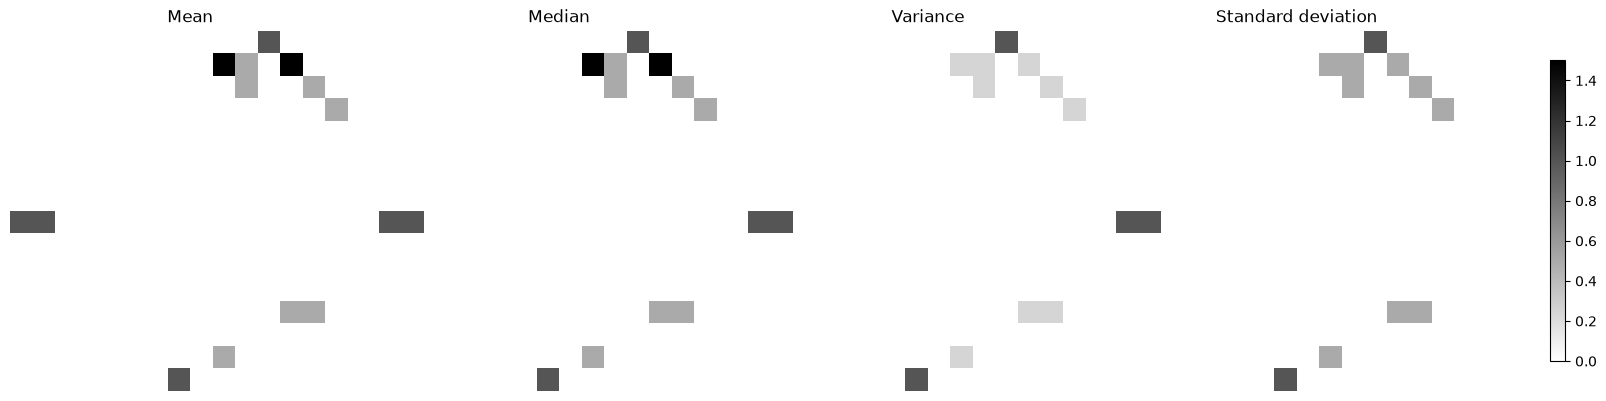

In [18]:
fig, axes = plt.subplots(
    1,
    len(matrices),
    figsize=(16, 4),
    constrained_layout=True
)

im = None

for ax, (name, matrix) in zip(axes, matrices.items()):
    _, _, im = matrix.plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(name)

fig.colorbar(
    im,
    ax=axes,
    shrink=0.8
)

plt.show()